# Séance 5 · Notebook 2 : extraire des caractéristiques de l'EEG

PSY2007D — Laboratoire 1, automne 2026

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Prétraitement et BIDS</div><div style="font-size:0.85em; color:#5B6472;">télécharger · organiser · nettoyer</div></td><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Caractéristiques</div><div style="font-size:0.85em; color:#C9D6E8;">ERP · spectres · temps-fréquence · 1/f · complexité · connectivité</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Apprentissage automatique</div><div style="font-size:0.85em; color:#5B6472;">décoder repos/mouvement et gauche/droite</div></td></tr></table>

Un essai d'EEG, c'est 64 canaux × 500 échantillons : trop de nombres pour être interprétés tels quels. Une **caractéristique** (*feature*) résume un essai en quelques nombres qui ont un sens : l'amplitude d'une onde, la puissance d'un rythme, la régularité du signal, le couplage entre deux régions. Ce notebook en calcule six familles, en commençant par la plus importante pour ce cours : **le spectre**.

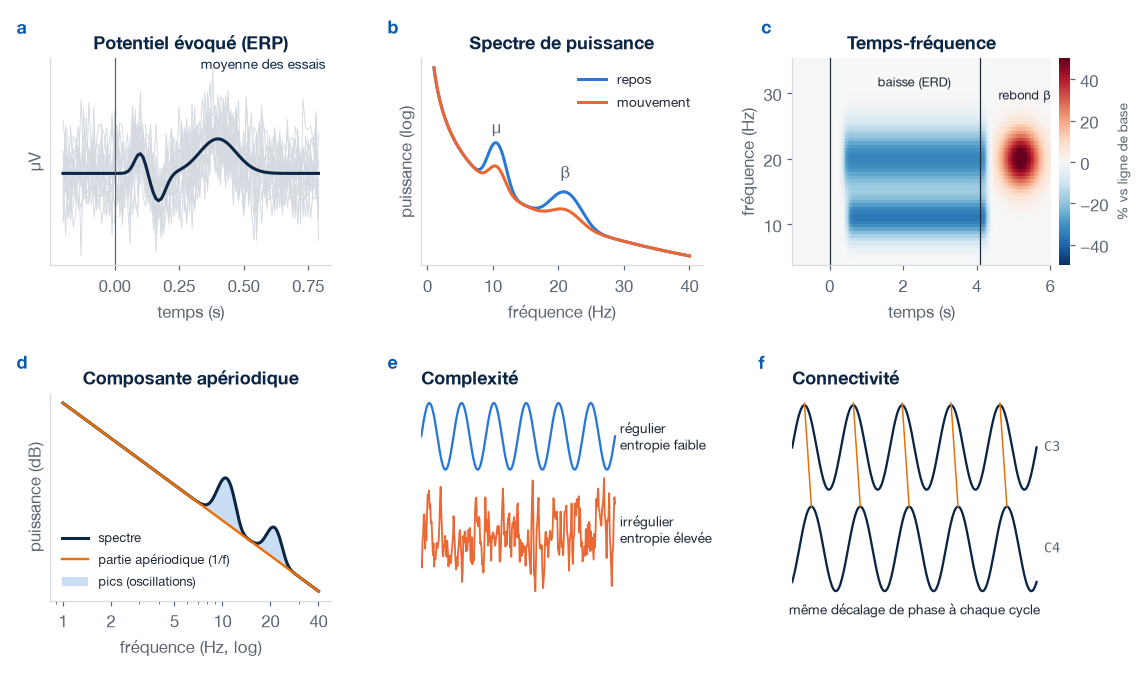

| Partie | Contenu |
|---|---|
| 0 | Charger les données propres du notebook 1 |
| 1 | Découper en essais (`Epochs`) |
| 2 | Potentiels évoqués (ERP) |
| 3 | **Spectres de puissance et bandes de fréquence** |
| 4 | Temps-fréquence |
| 5 | Composante apériodique (1/f) avec `specparam` |
| 6 | Complexité avec `antropy` |
| 7 | Connectivité avec `mne-connectivity` |
| 8 | Le tableau des caractéristiques (pour le notebook 3) |
| 9 | Récapitulatif |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Trois types de blocs</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;le code est complet : exécutez la cellule et lisez les commentaires.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complétez une ou deux lignes marquées <code>&lt;---</code>.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;écrivez la cellule vous-même, à partir des indices et des liens vers la documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Chaque exercice est suivi d'une solution repliée : essayez d'abord.</div></div>

In [ ]:
# ---- Installation (Colab seulement), imports et dossier des données
import sys
from pathlib import Path

DANS_COLAB = "google.colab" in sys.modules
if DANS_COLAB:
    !pip install -q mne mne-bids "mne-denoise[mne,viz]" mne-connectivity antropy specparam==2.0.0rc7
    !wget -q -N https://raw.githubusercontent.com/thecocolab/PSY2007D-UdeM/main/outils_seance5.py
    from google.colab import drive
    drive.mount("/content/drive")
    DOSSIER = Path("/content/drive/MyDrive/PSY2007D/donnees_seance5")
else:
    DOSSIER = Path("donnees_seance5")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import outils_seance5 as outils          # fonctions de la séance (fichier outils_seance5.py)

mne.set_log_level("WARNING")
COULEURS = {"repos": "#2a78d6", "mouvement": "#eb6834", "gauche": "#1baf7a", "droite": "#4a3aa7"}
print("MNE", mne.__version__)

## 0. Charger les données propres

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Retrouver les fichiers du notebook 1

`find_matching_paths` cherche dans `derivatives/pretraitement/` tous les fichiers dont les entités BIDS correspondent. Si rien n'est trouvé (notebook 1 non exécuté, nouvelle session Colab), la cellule refait tout le notebook 1 automatiquement avec les fonctions de `outils_seance5.py` : comptez quelques minutes.

In [ ]:
# ---- Trouver les fichiers prétraités ; les refaire s'ils manquent
from mne_bids import find_matching_paths

RACINE_PROPRE = DOSSIER / "derivatives" / "pretraitement"


def fichiers_propres():
    if not RACINE_PROPRE.exists():
        return []
    return find_matching_paths(RACINE_PROPRE, tasks="mouvement", processings="clean",
                               suffixes="eeg", extensions=".fif")


if not fichiers_propres():
    print("Données du notebook 1 introuvables : préparation automatique...")
    outils.preparer_donnees(DOSSIER)

SUJETS = sorted(int(chemin.subject) for chemin in fichiers_propres())
print(len(SUJETS), "participants :", SUJETS)

## 1. Découper en essais

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Des annotations aux epochs

On découpe le signal continu de **-1 à 4 s** autour de chaque indice (`repos`, `mouvement/gauche`, `mouvement/droite`). Un tableau de **métadonnées** accompagne les essais : une ligne par essai, avec la personne et la condition. C'est ce tableau qui deviendra, au notebook 3, la colonne des étiquettes.

In [ ]:
# ---- Les données propres d'un participant
SUJET_DEMO = 1
raw = mne.io.read_raw_fif(outils.chemin_propre(DOSSIER, SUJET_DEMO).fpath, preload=True)
print(raw)

events, _ = mne.events_from_annotations(raw, event_id=outils.EVENT_ID)
print(outils.EVENT_ID)
print(events[:5], "  (échantillon, 0, code)")

In [ ]:
# ---- Epochs de -1 à 4 s, avec un tableau de métadonnées
noms = {code_: nom for nom, code_ in outils.EVENT_ID.items()}            # 1 -> "repos", ...
etiquettes = [noms[code_] for code_ in events[:, 2]]
metadata = pd.DataFrame({
    "sujet": SUJET_DEMO,
    "condition": [e.split("/")[-1] for e in etiquettes],                 # repos, gauche, droite
    "mouvement": [int(e.startswith("mouvement")) for e in etiquettes],   # 0 = repos, 1 = mouvement
})
epochs = mne.Epochs(raw, events, outils.EVENT_ID, tmin=-1.0, tmax=4.0, baseline=None,
                    metadata=metadata, preload=True)
print(epochs)
epochs.metadata.head()

Quelques essais de repos manquent : ceux qui chevauchent une jonction entre runs ou le début de l'enregistrement ont été écartés. Les métadonnées suivent automatiquement.

La même opération pour n'importe quel participant est rangée dans une fonction (le code est identique, dans `outils_seance5.py`) :

In [ ]:
# ---- Epochs d'un participant quelconque
def charger_epochs(sujet, tmin=-1.0, tmax=4.0):
    raw_s = mne.io.read_raw_fif(outils.chemin_propre(DOSSIER, sujet).fpath, preload=True)
    return outils.decouper(raw_s, sujet, tmin=tmin, tmax=tmax)


print(charger_epochs(2))

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

1. Combien d'essais de **mouvement** (les deux mains) ? Rappel : `epochs["mouvement"]` sélectionne toutes les étiquettes qui contiennent `mouvement`.
2. Même question pour la main **droite** seulement.

In [ ]:
# ---- Exercice
# print(len(...))                                # <--- à compléter
# print(len(...))                                # <--- à compléter

In [ ]:
#@title Solution (à consulter après avoir essayé)
print("mouvement :", len(epochs["mouvement"]), "| droite :", len(epochs["droite"]))

## 2. Potentiels évoqués (ERP)

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : potentiel évoqué</b><br>Un <b>potentiel évoqué</b> est la réponse du cerveau <b>calée dans le temps</b> sur un événement. Dans un essai isolé, elle est noyée dans l'activité de fond. En faisant la <b>moyenne</b> de nombreux essais alignés sur l'indice, l'activité de fond (aléatoire d'un essai à l'autre) s'annule, et la réponse commune reste. Le bruit résiduel diminue comme 1/√N : 4 fois plus d'essais, bruit divisé par 2. La <b>ligne de base</b> (ici -0,2 à 0 s) sert de zéro : on soustrait à chaque essai sa moyenne avant l'indice.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> L'ERP d'un participant

Au moment où la cible apparaît (0 s), on attend une **réponse visuelle** à l'arrière de la tête, puis une activité liée au mouvement. On moyenne d'abord les deux mains ensemble (`"mouvement"`).

In [ ]:
# ---- Ligne de base, puis moyenne des essais de chaque condition
epochs_erp = epochs.copy().crop(-0.2, 0.8).apply_baseline((-0.2, 0))
evokeds = {c: epochs_erp[c].average() for c in ["repos", "mouvement", "gauche", "droite"]}
evokeds["mouvement"].plot_joint(times=[0.2, 0.4], title=f"S{SUJET_DEMO:03d}, mouvement (deux mains)");

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Tous les participants : la moyenne des moyennes

Un ERP par personne et par condition, puis la moyenne de ces ERP (*grand average*). Chaque personne compte autant, quel que soit son nombre d'essais.

In [ ]:
# ---- ERP de chaque participant, puis grand average (quelques secondes)
erps = {c: [] for c in ["repos", "mouvement", "gauche", "droite"]}
for sujet in SUJETS:
    ep = charger_epochs(sujet).crop(-0.2, 0.8).apply_baseline((-0.2, 0))
    for c in erps:
        erps[c].append(ep[c].average())

grand = {c: mne.grand_average(liste) for c, liste in erps.items()}
grand["mouvement"].plot_joint(times=[0.2, 0.4], title="Tous les participants, mouvement (deux mains)");

La réponse commence vers 0,2 s. Vers 0,4 s, une large onde est **positive à l'arrière** de la tête (régions pariétales et occipitales) et **négative à l'avant** : elle suit l'apparition de la cible et le début du mouvement. Comparons maintenant les deux mains au-dessus du cortex moteur.

In [ ]:
# ---- Main gauche vs main droite, à C3 (hémisphère gauche) et C4 (hémisphère droit)
mains = {"gauche": grand["gauche"], "droite": grand["droite"]}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, canal in zip(axes, ["C3", "C4"]):
    mne.viz.plot_compare_evokeds(mains, picks=canal, axes=ax, show=False, show_sensors=False,
                                 colors={m: COULEURS[m] for m in mains}, title=canal, legend="upper left")
plt.show()

Entre 0,3 et 0,5 s, le signal est **plus négatif du côté opposé à la main** : à C3 pour la main droite, à C4 pour la main gauche. Cela ressemble au **potentiel de préparation latéralisé** (LRP ; Coles, 1989 ; Eimer, 1998) : le cortex moteur gauche commande la main droite, et inversement. Mais regardons **où** se trouve la différence entre les deux mains.

In [ ]:
# ---- Où la différence gauche - droite se trouve-t-elle sur la tête ?
difference = mne.combine_evoked([grand["gauche"], grand["droite"]], weights=[1, -1])
difference.plot_topomap(times=[0.15, 0.3, 0.45], average=0.1, size=1.6);

La plus grande différence n'est **pas** au-dessus du cortex moteur : elle est **à l'avant, sur les côtés** (F7, F8, AF7, AF8), avec des signes opposés à gauche et à droite. Ce ne sont pas des neurones : la personne **déplace les yeux vers la cible**, à gauche ou à droite. L'œil est chargé électriquement (la cornée est positive par rapport à la rétine) ; quand il tourne, il crée un grand champ électrique à l'avant de la tête, qui s'étend jusqu'au centre.

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Attention</b><br>La chaîne du notebook 1 retire les <b>clignements</b>, pas les <b>mouvements horizontaux des yeux</b> (saccades). Ici, les yeux bougent toujours du même côté que la main : les deux effets sont <b>confondus</b>. Dans une vraie expérience, on demande de fixer une croix au centre, et on enregistre les yeux (électrodes EOG ou oculomètre).</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter : le LRP

Le LRP combine les deux mains pour ne garder que l'activité **controlatérale** (du côté opposé à la main) :

LRP = [ (C3 − C4) main droite + (C4 − C3) main gauche ] / 2

Complétez la ligne `lrp = ...` et tracez-le. Vous devriez voir une onde négative entre 0,3 et 0,5 s.

In [ ]:
# ---- Exercice
droite = grand["droite"].copy().pick(["C3", "C4"]).data * 1e6     # (2 canaux, temps) en µV ; ligne 0 = C3, ligne 1 = C4
gauche = grand["gauche"].copy().pick(["C3", "C4"]).data * 1e6
temps = grand["droite"].times

# lrp = ...                                     # <--- à compléter
# plt.plot(temps, lrp); plt.axhline(0, color="grey"); plt.xlabel("Temps (s)"); plt.ylabel("µV"); plt.show()

In [ ]:
#@title Solution (à consulter après avoir essayé)
lrp = ((droite[0] - droite[1]) + (gauche[1] - gauche[0])) / 2
plt.figure(figsize=(7, 3))
plt.plot(temps, lrp, color="#0B2545", lw=2)
plt.axhline(0, color="grey", lw=0.8); plt.axvline(0, color="grey", lw=0.8)
plt.xlabel("Temps (s)"); plt.ylabel("µV"); plt.title("LRP (tous les participants)")
plt.show()

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Le cerveau ou les yeux ? Une régression pour trancher

On fabrique un signal « yeux » : **F8 − F7**, la différence entre les deux électrodes les plus proches des yeux, à droite et à gauche. On l'appelle HEOG (électro-oculogramme horizontal). Puis, pour chaque canal, on fait une **régression linéaire** (comme en statistiques) : canal = b × HEOG + reste. Le « reste » est le signal du canal une fois retirée la part qui suit les yeux. On recalcule ensuite le LRP sur ce reste.

In [ ]:
# ---- LRP avant et après avoir retiré, par régression, ce qui suit les yeux (F8 - F7)
def lrp_essais(ep):
    """LRP (µV) d'un participant à partir de ses epochs de mouvement."""
    x = ep.get_data(picks=["C3", "C4"]) * 1e6
    main = ep.metadata.condition.to_numpy()
    return ((x[main == "droite", 0] - x[main == "droite", 1]).mean(axis=0)
            + (x[main == "gauche", 1] - x[main == "gauche", 0]).mean(axis=0)) / 2


def retirer_yeux(ep):
    """Pour chaque canal : régression sur HEOG = F8 - F7, on garde le résidu."""
    x = ep.get_data()                                                  # (essais, canaux, temps)
    heog = x[:, ep.ch_names.index("F8")] - x[:, ep.ch_names.index("F7")]
    propre = x.copy()
    for i in range(len(ep.ch_names)):
        b = np.sum(heog * x[:, i]) / np.sum(heog * heog)               # pente de la régression
        propre[:, i] = x[:, i] - b * heog
    return mne.EpochsArray(propre, ep.info, events=ep.events, event_id=ep.event_id, tmin=ep.tmin,
                           metadata=ep.metadata, on_missing="ignore", verbose=False)


lrp_avant, lrp_apres = [], []
for sujet in SUJETS:
    ep = charger_epochs(sujet)["mouvement"].crop(-0.2, 0.8).apply_baseline((-0.2, 0))
    lrp_avant.append(lrp_essais(ep))
    lrp_apres.append(lrp_essais(retirer_yeux(ep)))

temps = ep.times
plt.figure(figsize=(7.5, 3.3))
plt.plot(temps, np.mean(lrp_avant, axis=0), color="#9AA3AF", lw=2, label="avant")
plt.plot(temps, np.mean(lrp_apres, axis=0), color="#0B2545", lw=2, label="après retrait des yeux")
plt.axhline(0, color="grey", lw=0.8); plt.axvline(0, color="grey", lw=0.8)
plt.xlabel("Temps (s)"); plt.ylabel("µV"); plt.title("LRP moyen (tous les participants)"); plt.legend(frameon=False)
plt.show()
fenetre = (temps >= 0.3) & (temps < 0.5)
print("LRP moyen entre 0,3 et 0,5 s : %.1f µV avant, %.1f µV après" % (np.mean(lrp_avant, axis=0)[fenetre].mean(),
                                                                     np.mean(lrp_apres, axis=0)[fenetre].mean()))

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce qu'on observe (et ce que dit la littérature)</b><br>Une fois retirée la part qui suit les yeux, le LRP est <b>environ quatre fois plus petit</b>. Dans ces données, l'essentiel de l'onde latéralisée vient donc des yeux. La régression peut aussi retirer un peu d'activité cérébrale (F7 et F8 captent aussi le cerveau) : la vraie valeur se situe entre les deux courbes. Le LRP existe bel et bien (Coles, 1989 ; Eimer, 1998), mais il se mesure dans des tâches où les yeux restent au centre. Retenez surtout la démarche : quand un effet est latéralisé et que le stimulus est sur le côté, on vérifie toujours les yeux.</div>

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : la réponse visuelle latéralisée

La réponse visuelle arrive **avant** les yeux : vers 0,2 s, la cible n'a pas encore été regardée. Objectif : montrer que, vers 0,2 s, la réponse est plus négative du côté opposé à la cible, en comparant les deux mains (donc les deux côtés de la cible) à **PO7** (gauche) et **PO8** (droite).

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li>Reprenez la cellule « Main gauche vs main droite » et remplacez <code>["C3", "C4"]</code> par <code>["PO7", "PO8"]</code>.</li><li>Pour mieux voir le début, raccourcissez les ERP avant de les tracer : <code>{m: e.copy().crop(-0.1, 0.4) for m, e in mains.items()}</code>.</li><li>Documentation : <a href='https://mne.tools/stable/generated/mne.viz.plot_compare_evokeds.html'>plot_compare_evokeds</a>. Pour aller plus loin : Luck (2014), sur les composantes visuelles latéralisées.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
courts = {m: e.copy().crop(-0.1, 0.4) for m, e in mains.items()}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, canal in zip(axes, ["PO7", "PO8"]):
    mne.viz.plot_compare_evokeds(courts, picks=canal, axes=ax, show=False, show_sensors=False,
                                 colors={m: COULEURS[m] for m in courts}, title=canal, legend="upper left")
plt.show()
# Vers 0,2 s, PO7 (gauche) est plus négatif quand la cible est à droite, PO8 (droite) quand elle est à gauche :
# chaque hémisphère voit le côté opposé du champ visuel.

## 3. Spectres de puissance

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : spectre de puissance</b><br>Tout signal peut s'écrire comme une somme d'oscillations de fréquences différentes (transformée de Fourier). Le <b>spectre de puissance</b> (PSD, <i>power spectral density</i>) indique combien chaque fréquence contribue au signal. La <b>méthode de Welch</b> découpe la fenêtre en morceaux (ici 1 s), calcule le spectre de chacun et en fait la moyenne : le résultat est moins bruité. La <b>résolution</b> en fréquence vaut 1 / durée d'un morceau : 1 s donne des pas de 1 Hz.</div>

L'EEG se décrit par **bandes de fréquence**. Au-dessus du cortex moteur (C3, C4), le rythme de 8-13 Hz s'appelle **μ** (mu) ; au-dessus du cortex visuel, le rythme de même fréquence s'appelle **α** (alpha).

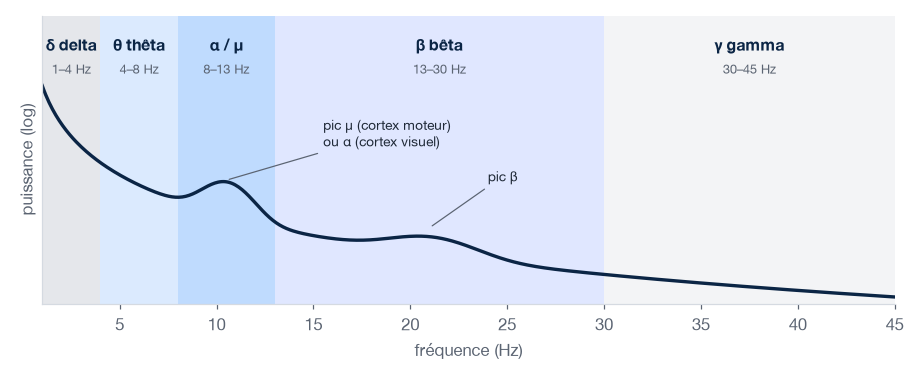

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Le spectre de chaque essai

On prend la fenêtre **0,5 à 4 s** : le mouvement est en cours, et on évite la réponse visuelle des premières centaines de millisecondes.

In [ ]:
# ---- Spectre de chaque essai et de chaque canal (Welch, morceaux de 1 s)
spectre = epochs.compute_psd(method="welch", tmin=0.5, tmax=4.0, fmin=2, fmax=40, n_fft=100)
freqs = spectre.freqs
print(spectre)
print("Forme :", spectre.get_data().shape, "= (essais, canaux, fréquences)")
print("Fréquences :", freqs[:4], "...", freqs[-1], "Hz")

In [ ]:
# ---- Spectre moyen à C3 : repos vs mouvement
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.axvspan(8, 13, color="#EEF3F9", lw=0); ax.axvspan(13, 30, color="#F5F3FF", lw=0)
for c in ["repos", "mouvement"]:
    p = spectre[c].get_data(picks="C3").mean(axis=0)[0] * 1e12      # moyenne des essais, en µV²/Hz
    ax.semilogy(freqs, p, color=COULEURS[c], lw=2.2, label=c)
ax.text(10.5, ax.get_ylim()[1] * 0.6, "μ", ha="center", fontsize=13, color="#5B6472")
ax.text(21.5, ax.get_ylim()[1] * 0.6, "β", ha="center", fontsize=13, color="#5B6472")
ax.set(xlabel="Fréquence (Hz)", ylabel="Puissance (µV²/Hz, échelle log)", title=f"S{SUJET_DEMO:03d}, C3")
ax.legend(frameon=False)
plt.show()

Au repos, le spectre de C3 a une **bosse vers 10-12 Hz** (le rythme μ) et une plus petite vers 20 Hz (β). Pendant le mouvement, les deux bosses **s'aplatissent** : c'est la **désynchronisation**. Les neurones du cortex moteur, qui oscillaient ensemble au repos, se mettent à travailler chacun de leur côté ; leurs petites oscillations ne s'additionnent plus.

L'axe vertical est **logarithmique** : la puissance décroît très vite avec la fréquence, et une échelle linéaire écraserait tout au-dessus de 10 Hz.

In [ ]:
# ---- Tous les canaux au repos (couleur = position), et la carte de la puissance par bande
spectre["repos"].average().plot(amplitude=False);
spectre["repos"].plot_topomap(bands={"μ 8-13 Hz": (8, 13), "β 13-30 Hz": (13, 30)}, dB=True);

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> De la courbe à un nombre : la puissance dans une bande

Pour comparer des essais (et, au notebook 3, pour les donner à un modèle), on résume le spectre par la **puissance moyenne dans chaque bande**. On en prend le logarithme : les valeurs deviennent plus symétriques et un écart de 1 correspond à un facteur 10.

In [ ]:
# ---- Puissance μ de chaque essai à C3
psd_c3 = spectre.get_data(picks="C3")[:, 0, :] * 1e12             # (essais, fréquences) en µV²/Hz
dans_mu = (freqs >= 8) & (freqs < 13)
mu_c3 = np.log10(psd_c3[:, dans_mu].mean(axis=1))                   # un nombre par essai

tableau = epochs.metadata.assign(mu_C3=mu_c3)
tableau.groupby("condition")["mu_C3"].describe().round(2)

In [ ]:
# ---- Les deux distributions se chevauchent : un essai isolé n'est pas toujours facile à classer
fig, ax = plt.subplots(figsize=(7, 3))
for c, valeur in [("repos", 0), ("mouvement", 1)]:
    ax.hist(tableau.loc[tableau.mouvement == valeur, "mu_C3"], bins=15, alpha=0.65, color=COULEURS[c], label=c)
ax.set(xlabel="log10 puissance μ à C3", ylabel="nombre d'essais"); ax.legend(frameon=False)
plt.show()

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> La désynchronisation (ERD), canal par canal

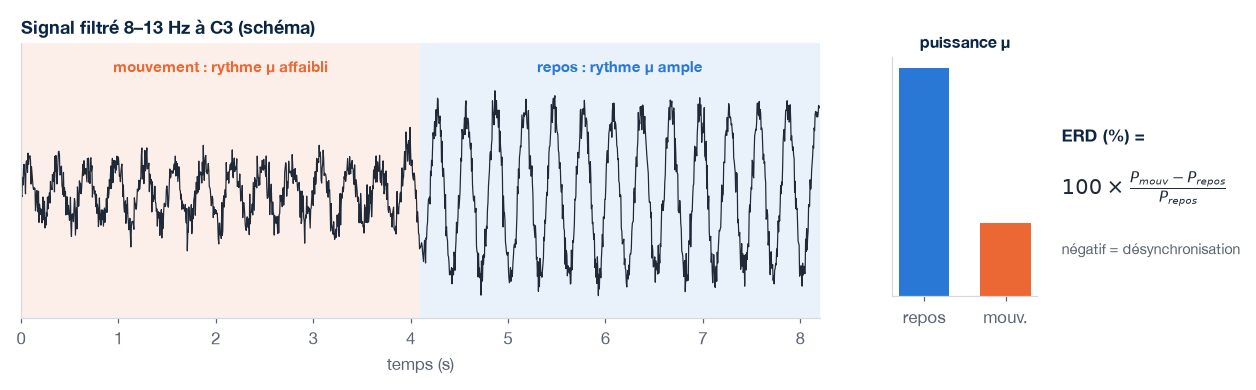

On calcule l'ERD de chaque canal pour chaque main, puis on la dessine sur la tête.

In [ ]:
# ---- Puissance moyenne dans une bande, pour chaque canal
def puissance_bande(spectre, condition, fmin, fmax):
    """Puissance moyenne (sur les essais et les fréquences de la bande), un nombre par canal."""
    p = spectre[condition].get_data()                                   # (essais, canaux, fréquences)
    dans_bande = (spectre.freqs >= fmin) & (spectre.freqs < fmax)
    return p[:, :, dans_bande].mean(axis=(0, 2))


def erd(spectre, main, fmin, fmax):
    """ERD (%) de chaque canal : 100 × (mouvement - repos) / repos."""
    repos = puissance_bande(spectre, "repos", fmin, fmax)
    return 100 * (puissance_bande(spectre, main, fmin, fmax) - repos) / repos


fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
for ax, main in zip(axes, ["gauche", "droite"]):
    im, _ = mne.viz.plot_topomap(erd(spectre, main, 8, 13), epochs.info, axes=ax, cmap="RdBu_r",
                                 vlim=(-60, 60), show=False)
    ax.set_title(f"main {main}", color=COULEURS[main])
fig.colorbar(im, ax=axes, shrink=0.75, label="ERD μ (%)")
plt.show()

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Tous les participants

On répète le calcul pour chaque personne, en μ et en β. On garde aussi le spectre moyen à C3 de chacun, réutilisé plus bas (parties 3 et 5).

In [ ]:
# ---- ERD de chaque participant (quelques secondes)
BANDES_ERD = {"μ": (8, 13), "β": (13, 30)}
erd_groupe = {(bande, main): [] for bande in BANDES_ERD for main in ["gauche", "droite"]}
spectres_c3 = []                                                    # spectre moyen à C3 de chaque personne

for sujet in SUJETS:
    sp = charger_epochs(sujet).compute_psd(method="welch", tmin=0.5, tmax=4.0, fmin=2, fmax=40, n_fft=100)
    for bande, (fmin, fmax) in BANDES_ERD.items():
        for main in ["gauche", "droite"]:
            erd_groupe[(bande, main)].append(erd(sp, main, fmin, fmax))
    spectres_c3.append({c: sp[c].get_data(picks="C3").mean(axis=0)[0] * 1e12 for c in ["repos", "mouvement"]})

erd_groupe = {cle: np.array(v) for cle, v in erd_groupe.items()}  # (participants, canaux)
print("Tableau par bande et par main :", erd_groupe[("μ", "gauche")].shape, "= (participants, canaux)")

In [ ]:
# ---- Moyenne des participants : où la puissance baisse-t-elle ?
fig, axes = plt.subplots(2, 2, figsize=(7, 6.4))
for i, bande in enumerate(BANDES_ERD):
    for j, main in enumerate(["gauche", "droite"]):
        im, _ = mne.viz.plot_topomap(erd_groupe[(bande, main)].mean(axis=0), epochs.info, axes=axes[i, j],
                                     cmap="RdBu_r", vlim=(-45, 45), show=False)
        axes[i, j].set_title(f"{bande}, main {main}")
fig.colorbar(im, ax=axes, shrink=0.6, label="ERD moyenne (%)")
plt.show()

In [ ]:
#@title Fonction de figure : valeurs appariées (exécuter ; pas besoin de lire le code)
def figure_appariee(ax, a, b, noms, couleurs, titre, ylabel):
    """Une ligne grise par participant entre deux conditions, et la moyenne en couleur."""
    a, b = np.asarray(a), np.asarray(b)
    for va, vb in zip(a, b):
        ax.plot([0, 1], [va, vb], color="#C3C9D2", lw=1, zorder=1)
    ax.scatter(np.zeros_like(a), a, color=couleurs[0], s=28, zorder=2)
    ax.scatter(np.ones_like(b), b, color=couleurs[1], s=28, zorder=2)
    ax.plot([0, 1], [a.mean(), b.mean()], color="#0B2545", lw=2.5, marker="o", ms=7, zorder=3)
    ax.set_xticks([0, 1], noms); ax.set_xlim(-0.4, 1.4); ax.set_ylabel(ylabel)
    ax.set_title(f"{titre}\n{np.sum(b > a)}/{len(a)} personnes : {noms[1]} > {noms[0]}", fontsize=10.5)

In [ ]:
# ---- C3 vs C4 pour chaque main : la baisse est-elle plus forte du côté opposé ?
ic3, ic4 = epochs.ch_names.index("C3"), epochs.ch_names.index("C4")
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for k, (bande, main) in enumerate([("μ", "gauche"), ("μ", "droite"), ("β", "gauche"), ("β", "droite")]):
    valeurs = erd_groupe[(bande, main)]
    figure_appariee(axes[k], valeurs[:, ic3], valeurs[:, ic4], ["C3", "C4"], ["#5B6472", "#5B6472"],
                    f"{bande}, main {main}", "ERD (%)" if k == 0 else "")
    axes[k].axhline(0, color="#9AA3AF", lw=0.8)
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce qu'on observe (et ce que dit la littérature)</b><br><ul style='margin:0;'><li>La puissance μ et β <b>baisse de 25 à 40 %</b> pendant le mouvement, surtout autour de C3, Cz et C4 (Pfurtscheller et Lopes da Silva, 1999).</li><li>Pour la <b>main droite</b>, la baisse est plus forte à <b>C3</b> (hémisphère gauche) chez la plupart des personnes : la désynchronisation est <b>controlatérale</b>.</li><li>Pour la <b>main gauche</b>, la baisse est plus bilatérale. Chez les droitiers, bouger la main non dominante active souvent les deux hémisphères.</li><li>À l'arrière (O1, Oz, O2), l'alpha baisse aussi un peu : la personne regarde la cible à l'écran.</li></ul></div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Et les yeux ?

On refait le calcul de l'ERD μ (main droite) après avoir retiré, par régression, ce qui suit les yeux (la fonction `retirer_yeux` de la partie 2).

In [ ]:
# ---- ERD μ à C3 et C4 (main droite), avec et sans la part qui suit les yeux
avec, sans = [], []
for sujet in SUJETS:
    ep = charger_epochs(sujet)
    for liste, e in [(avec, ep), (sans, retirer_yeux(ep))]:
        sp = e.compute_psd(method="welch", tmin=0.5, tmax=4.0, fmin=2, fmax=40, n_fft=100)
        valeurs = erd(sp, "droite", 8, 13)
        liste.append([valeurs[ic3], valeurs[ic4]])
print("ERD μ main droite (C3, C4) : %.0f %%, %.0f %% avec les yeux ; %.0f %%, %.0f %% sans"
      % (*np.mean(avec, axis=0), *np.mean(sans, axis=0)))

L'ERD ne bouge presque pas : la baisse de puissance μ ne vient pas des yeux. Le spectre de la fenêtre 0,5-4 s est plus robuste que l'ERP à cet artefact.

In [ ]:
# ---- Chaque personne est différente : spectre à C3 de chacun
n = len(SUJETS)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(2.6 * ((n + 1) // 2), 5), sharex=True)
for ax, sujet, sp in zip(axes.flat, SUJETS, spectres_c3):
    for c in ["repos", "mouvement"]:
        ax.semilogy(freqs, sp[c], color=COULEURS[c], lw=1.6, label=c)
    ax.set_title(f"S{sujet:03d}", fontsize=10); ax.set_yticks([], minor=True)
axes.flat[0].legend(frameon=False, fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Hz")
plt.tight_layout(); plt.show()

Certaines personnes ont un pic μ net au repos qui s'effondre pendant le mouvement ; d'autres n'ont presque pas de pic. La moyenne du groupe cache ces différences : au notebook 3, on verra qu'un modèle fonctionne mieux chez les unes que chez les autres (Blankertz et al., 2010).

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

1. Dessinez la carte de l'ERD **β** (13-30 Hz) de S001 pour la main droite : complétez les bornes de la bande.
2. Recalculez le spectre avec `n_fft=200` (morceaux de 2 s). Quelle est la nouvelle résolution en fréquence ? (`freqs[1] - freqs[0]`)

In [ ]:
# ---- Exercice
# carte = erd(spectre, "droite", fmin=..., fmax=...)                  # <--- à compléter
# mne.viz.plot_topomap(carte, epochs.info, cmap="RdBu_r", vlim=(-60, 60));

# spectre_fin = epochs.compute_psd(method="welch", tmin=0.5, tmax=4.0, fmin=2, fmax=40, n_fft=...)   # <--- à compléter
# print(spectre_fin.freqs[1] - spectre_fin.freqs[0], "Hz")

In [ ]:
#@title Solution (à consulter après avoir essayé)
carte = erd(spectre, "droite", fmin=13, fmax=30)
mne.viz.plot_topomap(carte, epochs.info, cmap="RdBu_r", vlim=(-60, 60));
spectre_fin = epochs.compute_psd(method="welch", tmin=0.5, tmax=4.0, fmin=2, fmax=40, n_fft=200)
print(spectre_fin.freqs[1] - spectre_fin.freqs[0], "Hz")      # 0,5 Hz : plus fin, mais chaque spectre est plus bruité

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : l'alpha occipital

Question : pendant le mouvement, la puissance alpha baisse-t-elle aussi à **Oz** (cortex visuel) ? Plus ou moins qu'à C3 ? Proposez une explication.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li><code>erd_groupe[("μ", "gauche")]</code> est un tableau (participants × canaux). La colonne d'un canal s'obtient avec son indice : <code>epochs.ch_names.index("Oz")</code>.</li><li>Faites la moyenne sur les participants (<code>.mean()</code>) pour Oz et pour C3, pour chaque main.</li><li>Pour l'explication : que regarde la personne pendant le mouvement ? Voir Pfurtscheller et Lopes da Silva (1999) sur l'alpha et l'attention visuelle.</li><li>Documentation : <a href='https://numpy.org/doc/stable/user/basics.indexing.html'>indexation NumPy</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
ioz = epochs.ch_names.index("Oz")
for main in ["gauche", "droite"]:
    v = erd_groupe[("μ", main)]
    print(f"main {main} : ERD alpha à Oz = {v[:, ioz].mean():.0f} %, à C3 = {v[:, ic3].mean():.0f} %")
# La baisse existe à Oz mais elle est plus faible qu'au-dessus du cortex moteur : pendant le mouvement,
# la personne regarde et suit la cible, ce qui désynchronise un peu l'alpha visuel.

## 4. Temps-fréquence

Le spectre de la partie 3 résume toute la fenêtre 0,5-4 s en une courbe : on perd le **moment** où la puissance change. Une analyse **temps-fréquence** calcule la puissance à chaque fréquence **et** à chaque instant.

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : temps-fréquence</b><br>On compare le signal à des <b>ondelettes de Morlet</b> : de courtes oscillations d'une fréquence donnée, qui glissent dans le temps. Plus l'ondelette a de cycles (<code>n_cycles</code>), plus la fréquence est précise et moins le temps l'est : c'est un compromis. On exprime ensuite la puissance par rapport à une <b>ligne de base</b> avant l'indice : −0,3 veut dire « 30 % de moins qu'avant l'indice ». Les bords de la fenêtre sont peu fiables (l'ondelette déborde) : on regarde le centre.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Un participant, main droite

On prend des epochs plus longues (-1,5 à 6,5 s) pour voir ce qui se passe **après** la fin du mouvement, à 4,1 s.

In [ ]:
# ---- Epochs longues, puis puissance temps-fréquence à C3, Cz, C4
epochs_longs = outils.decouper(raw, SUJET_DEMO, tmin=-1.5, tmax=6.5)
freqs_tf = np.arange(4, 36, 1.0)                                    # de 4 à 35 Hz, par pas de 1 Hz
tfr = epochs_longs["droite"].compute_tfr("morlet", freqs=freqs_tf, n_cycles=freqs_tf / 2,
                                         picks=["C3", "Cz", "C4"], average=True, decim=2)
print(tfr)

In [ ]:
# ---- Cartes temps-fréquence (bleu = baisse par rapport à -1 à -0,2 s ; rouge = hausse)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, canal in zip(axes, ["C3", "Cz", "C4"]):
    tfr.plot(picks=[canal], baseline=(-1.0, -0.2), mode="percent", vlim=(-0.8, 0.8), cmap="RdBu_r",
             axes=ax, show=False, colorbar=(canal == "C4"))
    ax.set_title(canal)
    for t in (0, 4.1):
        ax.axvline(t, color="black", lw=0.8)
plt.tight_layout(); plt.show()

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Tous les participants

In [ ]:
# ---- Temps-fréquence de chaque participant, pour chaque main, puis moyenne (environ 30 s)
tfr_groupe = {"gauche": [], "droite": []}
for sujet in SUJETS:
    ep = charger_epochs(sujet, tmin=-1.5, tmax=6.5)
    for main in tfr_groupe:
        t = ep[main].compute_tfr("morlet", freqs=freqs_tf, n_cycles=freqs_tf / 2,
                                 picks=["C3", "Cz", "C4"], average=True, decim=2)
        tfr_groupe[main].append(t.apply_baseline((-1.0, -0.2), mode="percent"))
tfr_moyen = {main: mne.grand_average(liste) for main, liste in tfr_groupe.items()}

fig, axes = plt.subplots(2, 3, figsize=(14, 6.6), sharex=True, sharey=True)
for i, main in enumerate(["gauche", "droite"]):
    for j, canal in enumerate(["C3", "Cz", "C4"]):
        tfr_moyen[main].plot(picks=[canal], vlim=(-0.5, 0.5), cmap="RdBu_r", axes=axes[i, j],
                             show=False, colorbar=(j == 2))
        axes[i, j].set_title(f"main {main}, {canal}")
        for t in (0, 4.1):
            axes[i, j].axvline(t, color="black", lw=0.8)
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce qu'on observe (et ce que dit la littérature)</b><br><ul style='margin:0;'><li>De 0,5 s environ jusqu'à la fin du mouvement : <b>baisse</b> (bleu) en μ et en β, plus nette du côté opposé à la main.</li><li>Juste après 0 s, une courte <b>hausse</b> (rouge) aux basses fréquences : c'est l'ERP de la partie 2, vu sous l'angle des fréquences.</li><li>Environ 0,5 à 1,5 s après la fin du mouvement (4,1 s) : <b>rebond β</b> (rouge vers 15-25 Hz), plus fort du côté opposé à la main. Ce rebond est un effet classique (Pfurtscheller et al., 1996).</li></ul></div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter : le compromis temps-fréquence

Refaites la carte de S001 à C3 avec **3 cycles** pour toutes les fréquences (`n_cycles=3`), puis avec **10 cycles**. Qu'est-ce qui devient flou dans chaque cas : le temps ou la fréquence ?

In [ ]:
# ---- Exercice
# for cycles in [3, 10]:
#     t = epochs_longs["droite"].compute_tfr("morlet", freqs=freqs_tf, n_cycles=..., picks=["C3"], average=True, decim=2)   # <--- à compléter
#     t.plot(baseline=(-1.0, -0.2), mode="percent", vlim=(-0.8, 0.8), cmap="RdBu_r", title=f"{cycles} cycles");

In [ ]:
#@title Solution (à consulter après avoir essayé)
for cycles in [3, 10]:
    t = epochs_longs["droite"].compute_tfr("morlet", freqs=freqs_tf, n_cycles=cycles, picks=["C3"], average=True, decim=2)
    t.plot(baseline=(-1.0, -0.2), mode="percent", vlim=(-0.8, 0.8), cmap="RdBu_r", title=f"{cycles} cycles");
# 3 cycles : les changements sont bien placés dans le temps, mais étalés en fréquence.
# 10 cycles : les bandes sont nettes en fréquence, mais les débuts et fins sont flous.

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : la carte du rebond β

Objectif : une carte de la tête montrant **où** se trouve le rebond β (15-25 Hz, 4,6 à 5,6 s) après un mouvement de la main droite, pour S001.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li>Calculez un temps-fréquence sur <b>tous</b> les canaux : même appel que plus haut, avec <code>picks="eeg"</code> (plus long : environ 10 s).</li><li>L'objet renvoyé a une méthode <code>plot_topomap(tmin=..., tmax=..., fmin=..., fmax=..., baseline=(-1.0, -0.2), mode="percent")</code>.</li><li>Comparez avec la même carte pendant le mouvement (1 à 3 s, 8-13 Hz).</li><li>Documentation : <a href='https://mne.tools/stable/generated/mne.time_frequency.AverageTFR.html#mne.time_frequency.AverageTFR.plot_topomap'>AverageTFR.plot_topomap</a>, exemple <a href='https://mne.tools/stable/auto_examples/time_frequency/time_frequency_erds.html'>ERDS maps</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
tfr_tous = epochs_longs["droite"].compute_tfr("morlet", freqs=freqs_tf, n_cycles=freqs_tf / 2,
                                              picks="eeg", average=True, decim=2)
fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
tfr_tous.plot_topomap(tmin=1.0, tmax=3.0, fmin=8, fmax=13, baseline=(-1.0, -0.2), mode="percent",
                      axes=axes[0], show=False, vlim=(-0.6, 0.6), cmap="RdBu_r")
axes[0].set_title("μ pendant le mouvement")
tfr_tous.plot_topomap(tmin=4.6, tmax=5.6, fmin=15, fmax=25, baseline=(-1.0, -0.2), mode="percent",
                      axes=axes[1], show=False, vlim=(-0.6, 0.6), cmap="RdBu_r")
axes[1].set_title("β après le mouvement")
plt.show()

## 5. La composante apériodique (1/f)

Le spectre de l'EEG n'est pas fait que de pics : sous les pics, la puissance décroît régulièrement avec la fréquence. Cette partie **apériodique** (souvent appelée « 1/f ») ne correspond pas à une oscillation ; elle reflèterait en partie l'équilibre entre excitation et inhibition dans le cortex. Si elle change, la puissance « dans la bande μ » change aussi, même sans aucune oscillation.

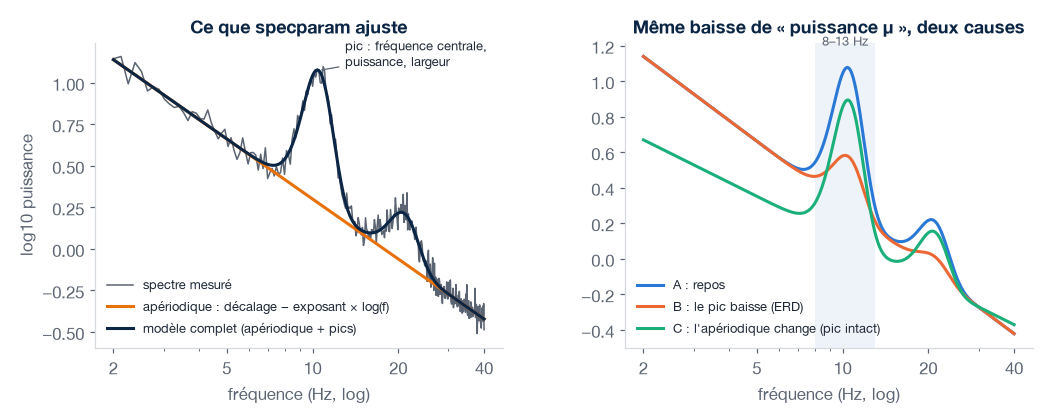

<div style="border-left:5px solid #0F766E; background:#E7F5F2; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0F766E;">Nouveau paquet : specparam</b><br><b>specparam</b> (anciennement FOOOF ; Donoghue et al., 2020) sépare un spectre en une composante apériodique (un <b>décalage</b> et un <b>exposant</b>, la pente en échelle log-log) et des <b>pics</b> (fréquence centrale, puissance au-dessus de l'apériodique, largeur). Nous utilisons la version 2.0. <a href='https://specparam-tools.github.io/'>Documentation</a></div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Ajuster le modèle sur un spectre

`report` ajuste le modèle, affiche les paramètres et trace le résultat : en noir le spectre, en rouge le modèle complet, en bleu pointillé la composante apériodique.

In [ ]:
# ---- Spectre moyen de C3 au repos : ajustement entre 3 et 40 Hz
from specparam import SpectralModel

psd_c3_repos = spectre["repos"].get_data(picks="C3").mean(axis=0)[0] * 1e12
modele = SpectralModel(peak_width_limits=(1, 8), max_n_peaks=4, aperiodic_mode="fixed", verbose=False)
modele.report(freqs, psd_c3_repos, freq_range=[3, 40])

In [ ]:
# ---- Les paramètres qu'on récupère
print("Exposant apériodique :", round(float(modele.get_params("aperiodic", "exponent")), 2))
print("Pics [fréquence (Hz), puissance, largeur (Hz)] :")
print(np.round(modele.get_params("periodic"), 2))

In [ ]:
#@title Fonction : exposant et pic μ d'un spectre (exécuter ; pas besoin de lire le code)
def exposant_et_pic_mu(freqs, psd):
    """Ajuste specparam et renvoie (exposant apériodique, puissance du pic 7-14 Hz ou 0 s'il n'y en a pas)."""
    m = SpectralModel(peak_width_limits=(1, 8), max_n_peaks=4, aperiodic_mode="fixed", verbose=False)
    m.fit(freqs, psd, [3, 40])
    pics = np.atleast_2d(m.get_params("periodic"))
    pics_mu = pics[(pics[:, 0] >= 7) & (pics[:, 0] <= 14)] if pics.size else []
    return float(m.get_params("aperiodic", "exponent")), float(pics_mu[0, 1]) if len(pics_mu) else 0.0

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Repos vs mouvement, pour tous les participants

On réutilise les spectres à C3 calculés en partie 3.

In [ ]:
# ---- Exposant et pic μ de chaque personne, au repos et pendant le mouvement
resultats = []
for sujet, sp in zip(SUJETS, spectres_c3):
    for c in ["repos", "mouvement"]:
        exposant, pic = exposant_et_pic_mu(freqs, sp[c])
        resultats.append({"sujet": sujet, "condition": c, "exposant": exposant, "pic_mu": pic})
resultats = pd.DataFrame(resultats).pivot(index="sujet", columns="condition")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
couleurs = [COULEURS["repos"], COULEURS["mouvement"]]
figure_appariee(axes[0], resultats["pic_mu"]["repos"], resultats["pic_mu"]["mouvement"], ["repos", "mouvement"],
                couleurs, "Pic μ (au-dessus de l'apériodique)", "puissance (log10)")
figure_appariee(axes[1], resultats["exposant"]["repos"], resultats["exposant"]["mouvement"], ["repos", "mouvement"],
                couleurs, "Exposant apériodique", "exposant")
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce qu'on observe (et ce que dit la littérature)</b><br>Le <b>pic μ</b> baisse pendant le mouvement chez la plupart des personnes qui en ont un au repos ; l'<b>exposant apériodique</b> ne change pas de façon régulière (il monte chez certains, baisse chez d'autres). La baisse de puissance de la partie 3 vient donc bien d'une <b>oscillation</b> qui disparaît, pas d'un changement du fond apériodique. Dans d'autres situations (âge, sommeil, médicaments), c'est l'exposant qui change : sans ce type d'analyse, on attribuerait à tort la différence à une oscillation (Donoghue et al., 2020). Un pic égal à 0 signifie qu'aucun pic μ n'a été détecté : certaines personnes n'en ont pas de visible.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

L'exposant dépend de la plage de fréquences ajustée. Refaites l'ajustement du spectre de repos de S001 entre **3 et 25 Hz**, puis entre **10 et 40 Hz**. L'exposant change-t-il beaucoup ?

In [ ]:
# ---- Exercice
# for plage in [[3, 25], [10, 40]]:
#     m = SpectralModel(peak_width_limits=(1, 8), max_n_peaks=4, aperiodic_mode="fixed", verbose=False)
#     m.fit(freqs, psd_c3_repos, ...)                                  # <--- à compléter
#     print(plage, round(float(m.get_params("aperiodic", "exponent")), 2))

In [ ]:
#@title Solution (à consulter après avoir essayé)
for plage in [[3, 25], [10, 40]]:
    m = SpectralModel(peak_width_limits=(1, 8), max_n_peaks=4, aperiodic_mode="fixed", verbose=False)
    m.fit(freqs, psd_c3_repos, plage)
    print(plage, round(float(m.get_params("aperiodic", "exponent")), 2))
# L'exposant varie selon la plage : il faut la choisir avant l'analyse et la garder pour tout le monde.

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : la carte de l'exposant

Objectif : une carte de la tête de l'exposant apériodique de S001 au repos (un ajustement par canal).

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li>Le spectre moyen de tous les canaux : <code>spectre["repos"].get_data().mean(axis=0) * 1e12</code> (canaux × fréquences).</li><li><code>SpectralGroupModel</code> (même paquet) ajuste plusieurs spectres d'un coup : <code>.fit(freqs, spectres, [3, 40])</code>, puis <code>.get_params("aperiodic", "exponent")</code> renvoie un exposant par canal.</li><li>Dessinez avec <code>mne.viz.plot_topomap(valeurs, epochs.info)</code>.</li><li>Documentation : <a href='https://specparam-tools.github.io/api.html'>API specparam</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
from specparam import SpectralGroupModel

spectres_repos = spectre["repos"].get_data().mean(axis=0) * 1e12
groupe = SpectralGroupModel(peak_width_limits=(1, 8), max_n_peaks=4, aperiodic_mode="fixed", verbose=False)
groupe.fit(freqs, spectres_repos, [3, 40])
exposants = groupe.get_params("aperiodic", "exponent")
im, _ = mne.viz.plot_topomap(exposants, epochs.info, cmap="viridis", show=False)
plt.colorbar(im, label="exposant"); plt.title("Exposant apériodique, repos"); plt.show()

## 6. Complexité

Deux signaux peuvent avoir la même puissance et pourtant être plus ou moins **prévisibles**. Les mesures de complexité quantifient cette régularité, sans passer par les fréquences.

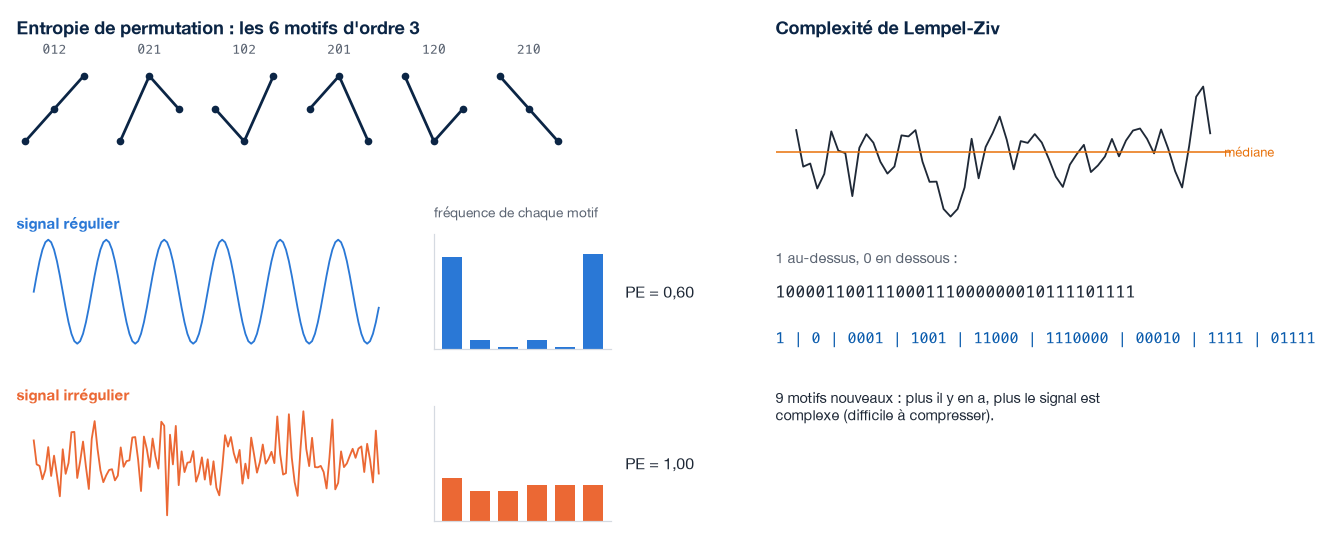

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : entropie de permutation et Lempel-Ziv</b><br><b>Entropie de permutation</b> (PE ; Bandt et Pompe, 2002) : on découpe le signal en petits groupes de points consécutifs (ici 3), on note l'ordre de leurs valeurs (le motif) et on compte la fréquence de chaque motif. Un signal régulier répète peu de motifs (PE faible) ; un signal imprévisible les utilise tous autant (PE proche de 1).<br><b>Complexité de Lempel-Ziv</b> (LZC ; Lempel et Ziv, 1976) : on transforme le signal en suite de 0 et de 1 (au-dessus ou en dessous de la médiane), puis on compte combien de nouveaux motifs il faut pour la décrire. Une suite qui se répète se compresse bien (LZC faible).</div>

<div style="border-left:5px solid #0F766E; background:#E7F5F2; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0F766E;">Nouveau paquet : antropy</b><br><b>antropy</b> regroupe des mesures d'entropie et de complexité pour les séries temporelles : entropie de permutation, entropie spectrale, Lempel-Ziv, dimension fractale, ... Chaque mesure est une simple fonction appliquée à un signal. <a href='https://raphaelvallat.com/antropy/'>Documentation</a></div>

In [ ]:
# ---- PE et LZC de chaque essai à C3, fenêtre 0,5 à 4 s
import antropy as ant

signal_c3 = epochs.copy().crop(0.5, 4.0).get_data(picks="C3")[:, 0, :]          # (essais, temps)
pe = np.array([ant.perm_entropy(x, order=3, delay=1, normalize=True) for x in signal_c3])
lz = np.array([ant.lziv_complexity(x > np.median(x), normalize=True) for x in signal_c3])

tableau = epochs.metadata.assign(pe_C3=pe, lz_C3=lz)
tableau.groupby("condition")[["pe_C3", "lz_C3"]].mean().round(3)

In [ ]:
# ---- Tous les participants : moyenne de chaque mesure au repos et pendant le mouvement
complexite = []
for sujet in SUJETS:
    ep = charger_epochs(sujet)
    x = ep.copy().crop(0.5, 4.0).get_data(picks="C3")[:, 0, :]
    for c, masque in [("repos", ep.metadata.mouvement.to_numpy() == 0), ("mouvement", ep.metadata.mouvement.to_numpy() == 1)]:
        complexite.append({
            "sujet": sujet, "condition": c,
            "pe": np.mean([ant.perm_entropy(v, order=3, delay=1, normalize=True) for v in x[masque]]),
            "lz": np.mean([ant.lziv_complexity(v > np.median(v), normalize=True) for v in x[masque]]),
        })
complexite = pd.DataFrame(complexite).pivot(index="sujet", columns="condition")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
figure_appariee(axes[0], complexite["pe"]["repos"], complexite["pe"]["mouvement"], ["repos", "mouvement"],
                couleurs, "Entropie de permutation (C3)", "PE")
figure_appariee(axes[1], complexite["lz"]["repos"], complexite["lz"]["mouvement"], ["repos", "mouvement"],
                couleurs, "Lempel-Ziv (C3)", "LZC")
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce qu'on observe</b><br>Les deux mesures ne vont <b>pas dans le même sens</b> :<ul style='margin:4px 0 0 0;'><li>la <b>PE augmente</b> pendant le mouvement chez tout le monde (l'écart est petit mais très régulier) : sans le rythme μ, le signal suit moins de motifs répétés ;</li><li>la <b>LZC baisse</b> chez la plupart des personnes : avec la médiane comme seuil, la LZC compte surtout les passages au-dessus et en dessous de la médiane. Quand l'oscillation à 10 Hz disparaît, il reste surtout des fluctuations lentes, donc moins de passages.</li></ul>Les mesures de complexité dépendent en partie du spectre. Avant d'interpréter « le cerveau est plus complexe », demandez-vous ce que la mesure détecte vraiment.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

Recalculez la PE de S001 avec des motifs de **4 points** (`order=4`) espacés de **2 échantillons** (`delay=2`). L'écart entre repos et mouvement change-t-il de sens ?

In [ ]:
# ---- Exercice
# pe4 = np.array([ant.perm_entropy(x, order=..., delay=..., normalize=True) for x in signal_c3])   # <--- à compléter
# print(epochs.metadata.assign(pe4=pe4).groupby("condition")["pe4"].mean())

In [ ]:
#@title Solution (à consulter après avoir essayé)
pe4 = np.array([ant.perm_entropy(x, order=4, delay=2, normalize=True) for x in signal_c3])
print(epochs.metadata.assign(pe4=pe4).groupby("condition")["pe4"].mean().round(3))
# Chez S001, l'écart devient minuscule et change même de sens : le résultat dépend des réglages.
# Il faut choisir order et delay avant l'analyse, et les garder pour tout le monde.

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : une troisième mesure

Choisissez une autre mesure d'`antropy` et comparez repos et mouvement pour S001 à C3 : l'**entropie spectrale** (`spectral_entropy`) ou la **dimension fractale de Higuchi** (`higuchi_fd`).

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li><code>ant.spectral_entropy(x, sf=100, method="welch", nperseg=100, normalize=True)</code> : 1 = spectre plat, 0 = une seule fréquence. Accepte directement un tableau 2D avec <code>axis=-1</code>.</li><li><code>ant.higuchi_fd(np.ascontiguousarray(x))</code> : autour de 1 pour un signal lisse, vers 2 pour un signal très irrégulier (cette fonction exige un tableau « contigu » en mémoire, d'où <code>np.ascontiguousarray</code>).</li><li>Réutilisez <code>signal_c3</code> et le tableau de métadonnées comme dans la cellule PE / LZC.</li><li>Documentation : <a href='https://raphaelvallat.com/antropy/api.html'>API antropy</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
se = ant.spectral_entropy(signal_c3, sf=100, method="welch", nperseg=100, normalize=True, axis=-1)
hfd = np.array([ant.higuchi_fd(np.ascontiguousarray(x)) for x in signal_c3])   # higuchi_fd exige un tableau « contigu » en mémoire
print(epochs.metadata.assign(se=se, hfd=hfd).groupby("condition")[["se", "hfd"]].mean().round(3))
# Chez S001, l'entropie spectrale et la dimension fractale baissent pendant le mouvement : sans le pic μ,
# la puissance se concentre dans les basses fréquences (comme pour la LZC).

## 7. Connectivité

Deux régions qui travaillent ensemble peuvent osciller **en phase** : leurs oscillations gardent un décalage constant d'un cycle à l'autre et d'un essai à l'autre. Les mesures de connectivité fonctionnelle quantifient cette constance.

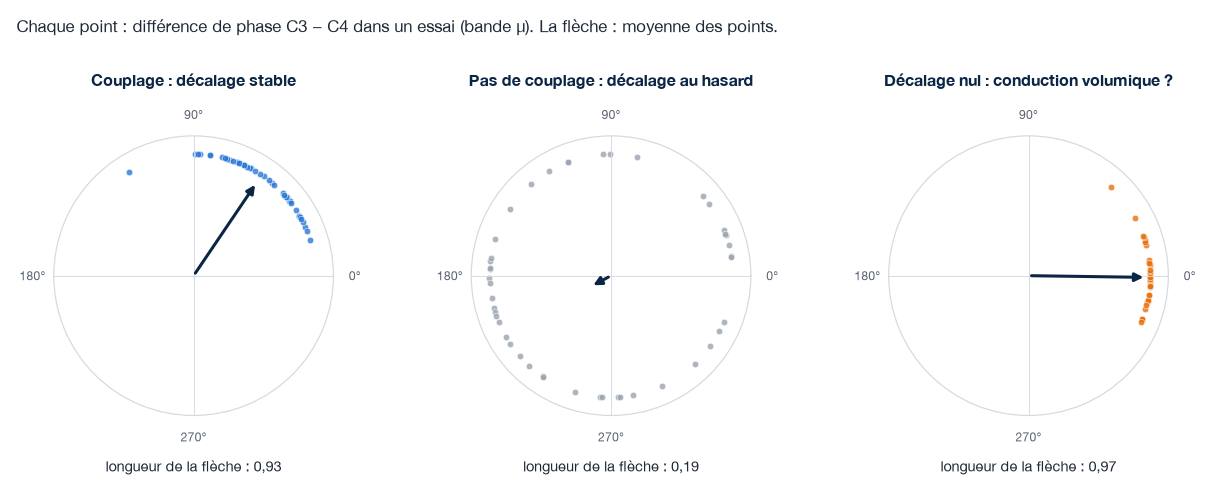

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : cohérence et wPLI</b><br><b>Cohérence</b> : mesure à quel point deux signaux ont, à une fréquence donnée, un rapport d'amplitude et un décalage de phase constants d'un essai à l'autre (0 = aucun lien, 1 = lien parfait).<br><b>wPLI</b> (<i>weighted phase lag index</i> ; Vinck et al., 2011) : ne compte que les décalages de phase <b>différents de 0° et de 180°</b>.<br>Pourquoi ? Une même source dans le cerveau est captée par plusieurs électrodes <b>au même instant</b> (conduction volumique) : cela crée de la cohérence sans aucune communication entre régions. Une vraie interaction prend du temps, donc produit un décalage (Nolte et al., 2004).</div>

<div style="border-left:5px solid #0F766E; background:#E7F5F2; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0F766E;">Nouveau paquet : mne-connectivity</b><br><b>MNE-Connectivity</b> calcule des mesures de connectivité (cohérence, PLV, wPLI, corrélation d'enveloppe, ...) à partir d'objets MNE. <a href='https://mne.tools/mne-connectivity/stable/index.html'>Documentation</a></div>

In [ ]:
# ---- Cohérence et wPLI dans la bande μ, entre toutes les paires de canaux (S001)
from mne_connectivity import spectral_connectivity_epochs

connectivite = {}
for c in ["repos", "mouvement"]:
    ep = epochs[c].copy().crop(0.5, 4.0)
    coh, wpli = spectral_connectivity_epochs(ep, method=["coh", "wpli2_debiased"], mode="multitaper",
                                             fmin=8, fmax=13, faverage=True)
    connectivite[c] = {}
    for nom, objet in [("cohérence", coh), ("wPLI", wpli)]:
        m = objet.get_data(output="dense")[:, :, 0]         # canaux × canaux, seul le triangle inférieur est rempli
        connectivite[c][nom] = m + m.T                       # on rend la matrice symétrique
print(connectivite["repos"]["cohérence"].shape, "= (canaux, canaux)")

`wpli2_debiased` est la version « débiaisée » du wPLI : avec peu d'essais, le wPLI simple surestime le lien ; cette version corrige ce biais. Une matrice 64 × 64 est difficile à lire ; on regarde plutôt une **carte « graine »** : le lien entre un canal choisi (C3) et tous les autres. Une carte d'une seule personne est bruitée : on fait la moyenne des participants.

In [ ]:
# ---- Carte « graine » : lien entre C3 et chaque autre canal, moyenne des participants (quelques secondes)
autres = np.array([i for i in range(len(epochs.ch_names)) if i != ic3])
cartes = {(mesure, c): [] for mesure in ["cohérence", "wPLI"] for c in ["repos", "mouvement"]}
for sujet in SUJETS:
    ep = charger_epochs(sujet)
    for c in ["repos", "mouvement"]:
        coh, wpli = spectral_connectivity_epochs(ep[c].copy().crop(0.5, 4.0), method=["coh", "wpli2_debiased"],
                                                 mode="multitaper", fmin=8, fmax=13, faverage=True,
                                                 indices=(np.full(len(autres), ic3), autres))   # C3 avec chacun des autres
        for mesure, objet in [("cohérence", coh), ("wPLI", wpli)]:
            cartes[(mesure, c)].append(np.insert(objet.get_data()[:, 0], ic3, 0.0))

masque = np.array([nom == "C3" for nom in epochs.ch_names])
fig, axes = plt.subplots(2, 2, figsize=(7, 6.4))
for i, (mesure, vmax) in enumerate([("cohérence", 0.6), ("wPLI", 0.4)]):
    for j, c in enumerate(["repos", "mouvement"]):
        valeurs = np.mean(cartes[(mesure, c)], axis=0)
        valeurs[ic3] = vmax                                            # C3 avec lui-même n'a pas de sens
        im, _ = mne.viz.plot_topomap(valeurs, epochs.info, axes=axes[i, j], cmap="Reds", show=False,
                                     vlim=(0, vmax), mask=masque,
                                     mask_params=dict(marker="o", markerfacecolor="white", markersize=8))
        axes[i, j].set_title(f"{mesure} avec C3\n{c}", fontsize=10)
    fig.colorbar(im, ax=axes[i], shrink=0.8)
plt.show()

La **cohérence** est maximale **autour de C3** : les électrodes voisines captent en grande partie les mêmes sources (conduction volumique). Le **wPLI** fait disparaître cette tache : les voisins immédiats n'ont plus de lien particulier. Il reste des liens plus lointains (vers l'arrière de C3, vers la tempe droite) ; leur origine demanderait d'autres analyses, et les bords de la carte sont les moins fiables.

In [ ]:
# ---- Tous les participants : lien C3 - C4 (bande μ), repos vs mouvement
lien = []
for sujet in SUJETS:
    ep = charger_epochs(sujet)
    for c in ["repos", "mouvement"]:
        coh, wpli = spectral_connectivity_epochs(ep[c].copy().crop(0.5, 4.0), method=["coh", "wpli2_debiased"],
                                                 mode="multitaper", fmin=8, fmax=13, faverage=True,
                                                 indices=(np.array([ic3]), np.array([ic4])))
        lien.append({"sujet": sujet, "condition": c, "coh": coh.get_data()[0, 0], "wpli": wpli.get_data()[0, 0]})
lien = pd.DataFrame(lien).pivot(index="sujet", columns="condition")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
figure_appariee(axes[0], lien["coh"]["repos"], lien["coh"]["mouvement"], ["repos", "mouvement"],
                couleurs, "Cohérence C3 - C4 (μ)", "cohérence")
figure_appariee(axes[1], lien["wpli"]["repos"], lien["wpli"]["mouvement"], ["repos", "mouvement"],
                couleurs, "wPLI C3 - C4 (μ)", "wPLI (débiaisé)")
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce qu'on observe</b><br>La <b>cohérence</b> C3-C4 baisse pendant le mouvement chez la plupart des personnes ; le <b>wPLI</b> baisse un peu en moyenne, mais de façon beaucoup moins régulière. Deux explications à la baisse de cohérence, sans « communication » en jeu : la puissance μ baisse (moins de signal, donc une estimation de phase plus bruitée), et la part de conduction volumique change. La connectivité se mesure facilement, mais s'interprète difficilement : il faut toujours regarder la puissance en même temps.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

Refaites la carte « graine » de S001 dans la bande **β** (13-30 Hz), au repos, pour la cohérence. Complétez `fmin` et `fmax`.

In [ ]:
# ---- Exercice
# coh_beta = spectral_connectivity_epochs(epochs["repos"].copy().crop(0.5, 4.0), method="coh", mode="multitaper",
#                                         fmin=..., fmax=..., faverage=True)            # <--- à compléter
# m = coh_beta.get_data(output="dense")[:, :, 0]; m = m + m.T
# mne.viz.plot_topomap(m[ic3], epochs.info, cmap="Reds", vlim=(0, 0.6));

In [ ]:
#@title Solution (à consulter après avoir essayé)
coh_beta = spectral_connectivity_epochs(epochs["repos"].copy().crop(0.5, 4.0), method="coh", mode="multitaper",
                                        fmin=13, fmax=30, faverage=True)
m = coh_beta.get_data(output="dense")[:, :, 0]; m = m + m.T
mne.viz.plot_topomap(m[ic3], epochs.info, cmap="Reds", vlim=(0, 0.6));

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : les liens les plus forts

Objectif : afficher les 20 paires de canaux les plus liées (wPLI, bande μ, repos, S001) sur un diagramme circulaire.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li>La matrice est dans <code>connectivite["repos"]["wPLI"]</code> (canaux × canaux).</li><li><code>from mne_connectivity.viz import plot_connectivity_circle</code>, puis <code>plot_connectivity_circle(matrice, epochs.ch_names, n_lines=20)</code>.</li><li>Documentation : <a href='https://mne.tools/mne-connectivity/stable/generated/mne_connectivity.viz.plot_connectivity_circle.html'>plot_connectivity_circle</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
from mne_connectivity.viz import plot_connectivity_circle

plot_connectivity_circle(connectivite["repos"]["wPLI"], epochs.ch_names, n_lines=20,
                         title="wPLI μ, repos : 20 liens les plus forts", facecolor="white", textcolor="black");

## 8. Le tableau des caractéristiques

Le notebook 3 a besoin d'un tableau : **une ligne par essai**, une colonne par caractéristique, plus les colonnes qui décrivent l'essai (participant, condition). Chaque caractéristique est calculée pour **chaque canal** ; son nom combine la mesure et le canal : `mu_C3` est la puissance μ à C3.

| Colonnes | Mesure | Fenêtre |
|---|---|---|
| `theta_…`, `mu_…`, `beta_…` | log10 de la puissance dans la bande (µV²/Hz) | 0,5 à 4 s |
| `expo_…` | exposant apériodique (specparam, un ajustement par essai et par canal) | 0,5 à 4 s |
| `pe_…`, `lz_…` | entropie de permutation, Lempel-Ziv | 0,5 à 4 s |
| `erp100_…`, `erp300_…` | amplitude moyenne (µV) entre 100 et 200 ms, entre 300 et 500 ms | ligne de base -0,2 à 0 s |

La connectivité n'y figure pas : elle se calcule sur un ensemble d'essais, pas sur un essai isolé.

In [ ]:
# ---- Une fonction : epochs -> tableau (une ligne par essai)
import antropy as ant
from specparam import SpectralGroupModel

BANDES = {"theta": (4, 8), "mu": (8, 13), "beta": (13, 30)}
FENETRES_ERP = {"erp100": (0.10, 0.20), "erp300": (0.30, 0.50)}


def caracteristiques_essais(epochs):
    """Tableau pandas : une ligne par essai, une colonne par (mesure, canal)."""
    canaux = epochs.ch_names
    colonnes = {}

    # 1. Puissance par bande (log10 µV²/Hz), fenêtre 0,5 à 4 s
    spectre = epochs.compute_psd(method="welch", tmin=0.5, tmax=4.0, fmin=2, fmax=40, n_fft=100, verbose=False)
    psd, freqs = spectre.get_data() * 1e12, spectre.freqs
    for bande, (fmin, fmax) in BANDES.items():
        puissance = np.log10(psd[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1))
        colonnes.update({f"{bande}_{c}": puissance[:, i] for i, c in enumerate(canaux)})

    # 2. Exposant apériodique (specparam), un ajustement par essai et par canal
    modele = SpectralGroupModel(peak_width_limits=(1, 8), max_n_peaks=3, aperiodic_mode="fixed", verbose=False)
    modele.fit(freqs, psd.reshape(-1, len(freqs)), freq_range=(3, 40))
    exposant = modele.get_params("aperiodic", "exponent").reshape(len(epochs), len(canaux))
    colonnes.update({f"expo_{c}": exposant[:, i] for i, c in enumerate(canaux)})

    # 3. Complexité : entropie de permutation et Lempel-Ziv, fenêtre 0,5 à 4 s
    x = epochs.copy().crop(0.5, 4.0).get_data()
    pe = np.apply_along_axis(lambda s: ant.perm_entropy(s, order=3, delay=1, normalize=True), -1, x)
    lz = np.apply_along_axis(lambda s: ant.lziv_complexity(s > np.median(s), normalize=True), -1, x)
    colonnes.update({f"pe_{c}": pe[:, i] for i, c in enumerate(canaux)})
    colonnes.update({f"lz_{c}": lz[:, i] for i, c in enumerate(canaux)})

    # 4. ERP : amplitude moyenne (µV) dans deux fenêtres, ligne de base -0,2 à 0 s
    erp = epochs.copy().crop(-0.2, 0.8).apply_baseline((-0.2, 0), verbose=False)
    for nom, (debut, fin) in FENETRES_ERP.items():
        amplitude = erp.copy().crop(debut, fin).get_data().mean(axis=-1) * 1e6
        colonnes.update({f"{nom}_{c}": amplitude[:, i] for i, c in enumerate(canaux)})

    tableau = pd.concat([epochs.metadata.reset_index(drop=True), pd.DataFrame(colonnes)], axis=1)
    tableau.insert(1, "essai", np.arange(len(tableau)))
    return tableau

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Tous les participants, puis enregistrement

Environ 15 secondes par personne (l'ajustement de specparam sur chaque essai et chaque canal est l'étape la plus longue). On enregistre aussi des epochs courtes (-0,2 à 1 s), utilisées au notebook 3 pour le décodage dans le temps.

In [ ]:
# ---- Calculer, puis enregistrer dans derivatives/caracteristiques
import time

tableaux = []
for sujet in SUJETS:
    debut = time.time()
    ep = charger_epochs(sujet)
    tableaux.append(caracteristiques_essais(ep))

    erp = ep.copy().crop(-0.2, 1.0).apply_baseline((-0.2, 0))           # pour le notebook 3
    sortie = outils.chemin_epochs_erp(DOSSIER, sujet)
    sortie.mkdir()
    erp.save(sortie.fpath, overwrite=True)
    print(f"S{sujet:03d} : {time.time() - debut:.0f} s")

caracteristiques = pd.concat(tableaux, ignore_index=True)
fichier = outils.chemin_caracteristiques(DOSSIER)
fichier.parent.mkdir(parents=True, exist_ok=True)
caracteristiques.to_csv(fichier, index=False)
print(caracteristiques.shape, "->", fichier)

In [ ]:
# ---- Aperçu : les colonnes de description et quelques caractéristiques de C3
caracteristiques[["sujet", "essai", "condition", "mouvement", "mu_C3", "beta_C3", "expo_C3", "pe_C3", "erp300_C3"]].head()

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

1. Moyenne de `beta_C3` par condition, pour tous les participants (`groupby`).
2. Combien de colonnes commencent par `mu_` ? (`caracteristiques.filter(like="mu_")`)

In [ ]:
# ---- Exercice
# print(caracteristiques.groupby(...)["beta_C3"].mean())             # <--- à compléter
# print(caracteristiques.filter(like=...).shape[1])                  # <--- à compléter

In [ ]:
#@title Solution (à consulter après avoir essayé)
print(caracteristiques.groupby("condition")["beta_C3"].mean().round(3))
print(caracteristiques.filter(like="mu_").shape[1], "colonnes mu_ (une par canal)")

## 9. Récapitulatif

| Mesure | Ce qu'elle résume | Fonction | Ici (repos → mouvement) |
|---|---|---|---|
| ERP | réponse calée sur l'indice | `epochs.average()` | réponse visuelle ; l'onde latéralisée à C3/C4 vient surtout des yeux |
| Spectre, bandes | puissance par fréquence | `compute_psd`, puissance dans une bande | μ et β baissent de 25 à 40 % autour de C3/C4 |
| Temps-fréquence | puissance par fréquence et par instant | `compute_tfr("morlet")` | baisse pendant le mouvement, rebond β après |
| Apériodique (1/f) | fond du spectre, sans les pics | `specparam.SpectralModel` | le pic μ baisse ; l'exposant ne change pas de façon régulière |
| Complexité | régularité du signal | `antropy.perm_entropy`, `lziv_complexity` | PE monte, LZC baisse : les deux dépendent du spectre |
| Connectivité | constance des décalages de phase | `spectral_connectivity_epochs` | la cohérence baisse, pas le wPLI |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">À retenir</b><br><ul style='margin:0;'><li>Le spectre est la mesure la plus directe des oscillations : la plupart des autres mesures en dépendent en partie.</li><li>Comparer au repos (ligne de base) donne des effets lisibles : l'ERD en pourcentage, le temps-fréquence en variation relative.</li><li>Les effets de groupe sont nets, mais chaque personne est différente.</li><li>Les mouvements des yeux dominent l'ERP latéralisé ; la baisse de puissance μ/β, elle, ne change pas quand on retire les yeux. On en reparle au notebook 3.</li></ul></div>

**Suite** : `seance5_3_apprentissage.ipynb` lit `derivatives/caracteristiques/caracteristiques_essais.csv`.

<details><summary>Références</summary>

- Bandt, C., & Pompe, B. (2002). Permutation entropy: A natural complexity measure for time series. *Physical Review Letters*, 88(17), 174102.
- Blankertz, B., et al. (2010). Neurophysiological predictor of SMR-based BCI performance. *NeuroImage*, 51(4), 1303-1309.
- Coles, M. G. H. (1989). Modern mind-brain reading: Psychophysiology, physiology, and cognition. *Psychophysiology*, 26(3), 251-269.
- Donoghue, T., et al. (2020). Parameterizing neural power spectra into periodic and aperiodic components. *Nature Neuroscience*, 23, 1655-1665.
- Eimer, M. (1998). The lateralized readiness potential as an on-line measure of central response activation processes. *Behavior Research Methods, Instruments, & Computers*, 30, 146-156.
- Lempel, A., & Ziv, J. (1976). On the complexity of finite sequences. *IEEE Transactions on Information Theory*, 22(1), 75-81.
- Luck, S. J. (2014). *An Introduction to the Event-Related Potential Technique* (2e éd.). MIT Press.
- Nolte, G., et al. (2004). Identifying true brain interaction from EEG data using the imaginary part of coherency. *Clinical Neurophysiology*, 115(10), 2292-2307.
- Pfurtscheller, G., & Lopes da Silva, F. H. (1999). Event-related EEG/MEG synchronization and desynchronization: Basic principles. *Clinical Neurophysiology*, 110(11), 1842-1857.
- Pfurtscheller, G., Stancák, A., & Neuper, C. (1996). Post-movement beta synchronization. A correlate of an idling motor area? *Electroencephalography and Clinical Neurophysiology*, 98(4), 281-293.
- Vinck, M., et al. (2011). An improved index of phase-synchronization for electrophysiological data in the presence of volume-conduction, noise and sample-size bias. *NeuroImage*, 55(4), 1548-1565.
</details>